In [107]:
!pip install yfinance

/opt/conda/lib/python3.10/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


In [108]:
!pip install ta

In [109]:
!pip uninstall -y cffi pycryptodome oauth2client google-api-python-client
!pip install cffi==2.0.0
!pip install pycryptodome oauth2client google-api-python-client
import tensorflow as tf
print(tf.__version__)

Found existing installation: cffi 2.0.0
Uninstalling cffi-2.0.0:
  Successfully uninstalled cffi-2.0.0
Found existing installation: pycryptodome 3.23.0
Uninstalling pycryptodome-3.23.0:
  Successfully uninstalled pycryptodome-3.23.0
Found existing installation: oauth2client 4.1.3
Uninstalling oauth2client-4.1.3:
  Successfully uninstalled oauth2client-4.1.3
Found existing installation: google-api-python-client 2.194.0
Uninstalling google-api-python-client-2.194.0:
  Successfully uninstalled google-api-python-client-2.194.0
  Using cached cffi-2.0.0-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (2.6 kB)
Using cached cffi-2.0.0-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (216 kB)
  Using cached pycryptodome-3.23.0-cp37-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (3.4 kB)
  Using cached oauth2client-4.1.3-py2.py3-none-any.whl.metadata (1.2 kB)
  Using cached google_api_python_client-2.194.0-py3-none-any.whl.metadata (7.0 kB)
Using cach

In [110]:
import yfinance as yf
import pandas as pd
import numpy as np
import ta  # Technical Analysis library
from sklearn.preprocessing import MinMaxScaler

In [ ]:
# List of stocks used in the study (can switch ticker to run for different stocks)
tickers = [
    "HDFCBANK.NS", "DCB.NS", "M&M.NS",
    "ASHOKLEY.NS", "JSWSTEEL.NS",
    "JINDALSTEL.NS", "SUNPHARMA.NS", "AUROPHARMA.NS"
]
ticker = 'AUROPHARMA.NS'

# Download data from 2010-01-01 to the most recent available date
new_data = yf.download(ticker, start='2010-01-01', end='2024-01-01')

# Preview the new data
print(new_data.head())


[*********************100%***********************]  1 of 1 completed

Price              Close          High           Low          Open  \
Ticker     AUROPHARMA.NS AUROPHARMA.NS AUROPHARMA.NS AUROPHARMA.NS   
Date                                                                 
2010-01-04     83.299774     83.573861     80.725162     82.225895   
2010-01-05     82.338211     84.912823     80.967778     84.912823   
2010-01-06     81.547424     83.187446     81.017221     82.585357   
2010-01-07     79.866959     82.468529     79.637807     82.468529   
2010-01-08     80.549934     81.686718     79.260376     79.866963   

Price             Volume  
Ticker     AUROPHARMA.NS  
Date                      
2010-01-04       1352610  
2010-01-05       1147940  
2010-01-06       1571850  
2010-01-07       1824660  
2010-01-08       1433440  


In [112]:
# Access the 'Close' column using the correct multi-level index
close_prices = new_data[('Close', ticker)]

# Check if it is a 1D pandas Series
print(close_prices.shape) 


(3454,)


In [113]:
# Access the 'Close' column using the correct multi-level index
close_prices = new_data[('Close', ticker)]

# Step 3: Calculate technical indicators
# Calculate 20-period SMA (Simple Moving Average)
new_data[('SMA_20', '')] = new_data[('Close', ticker)].rolling(window=20).mean()

# Calculate 20-period EMA (Exponential Moving Average)
new_data[('EMA_20', '')] = new_data[('Close', ticker)].ewm(span=20, adjust=False).mean()

# Calculate 14-period RSI (Relative Strength Index)
new_data[('RSI', '')] = ta.momentum.RSIIndicator(close_prices, window=14).rsi()

# Calculate Bollinger Bands (Upper and Lower)
new_data[('Bollinger_Upper', '')] = new_data[('SMA_20', '')] + 2 * new_data[('Close', ticker)].rolling(window=20).std()
new_data[('Bollinger_Lower', '')] = new_data[('SMA_20', '')] - 2 * new_data[('Close', ticker)].rolling(window=20).std()


# Handle NaN values caused by rolling calculations (forward fill or drop)
new_data.ffill(inplace=True)

new_data.dropna(inplace=True)  # Alternatively, drop rows with NaN values

# Preview the data with the new technical indicators
print(new_data.head())


Price              Close          High           Low          Open  \
Ticker     AUROPHARMA.NS AUROPHARMA.NS AUROPHARMA.NS AUROPHARMA.NS   
Date                                                                 
2010-02-01     80.176987     80.437594     76.834031     76.834031   
2010-02-02     79.741127     81.533923     79.273829     80.877910   
2010-02-03     81.062157     81.655258     80.073650     80.850975   
2010-02-04     82.616814     83.834479     79.979296     80.873449   
2010-02-05     78.483040     82.386901     77.085579     81.156238   

Price             Volume     SMA_20     EMA_20        RSI Bollinger_Upper  \
Ticker     AUROPHARMA.NS                                                    
Date                                                                        
2010-02-01       2688910  79.822246  79.681846  49.925204       83.872473   
2010-02-02       1437100  79.644314  79.687492  48.466673       83.349240   
2010-02-03       2292510  79.580511  79.818412  52.952

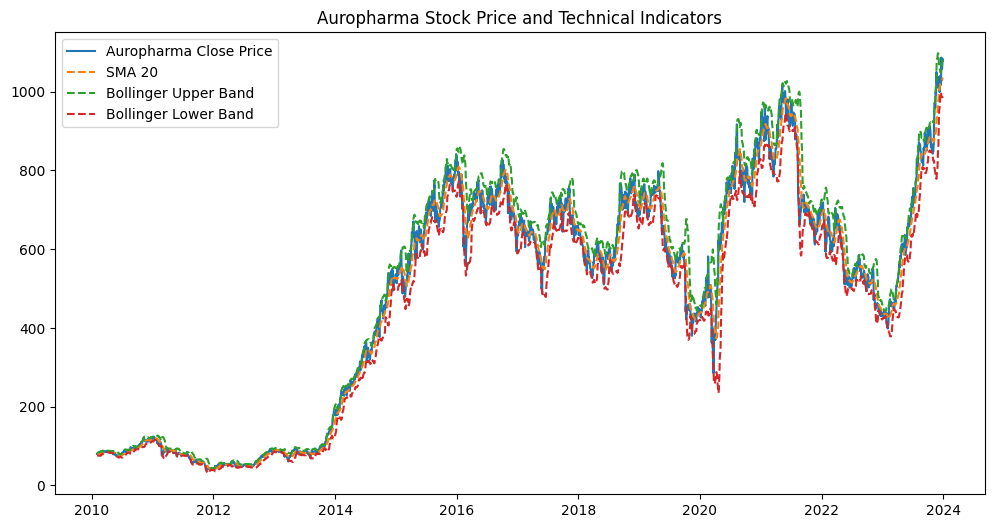

In [114]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(new_data['Close'], label='Auropharma Close Price')
plt.plot(new_data['SMA_20'], label='SMA 20', linestyle='--')
plt.plot(new_data['Bollinger_Upper'], label='Bollinger Upper Band', linestyle='--')
plt.plot(new_data['Bollinger_Lower'], label='Bollinger Lower Band', linestyle='--')
plt.legend(loc='best')
plt.title('Auropharma Stock Price and Technical Indicators')
plt.show()


In [115]:
from sklearn.preprocessing import MinMaxScaler

# Define the columns to normalize
features_to_normalize = ['Open', 'High', 'Low', 'Close', 'Volume', 
                         'SMA_20', 'EMA_20', 'RSI', 'Bollinger_Upper', 'Bollinger_Lower']
n=len(new_data)
train_end=int(n*0.70)
val_end=int(n*0.85)
train_data = new_data.iloc[:train_end].copy()
val_data   = new_data.iloc[train_end:val_end].copy()
test_data  = new_data.iloc[val_end:].copy()
 
# Step 2 — fit scaler on training data ONLY
scaler = MinMaxScaler()
train_data[features_to_normalize] = scaler.fit_transform(
    train_data[features_to_normalize])
 
# Step 3 — transform val and test using training statistics
val_data[features_to_normalize]  = scaler.transform(
    val_data[features_to_normalize])
test_data[features_to_normalize] = scaler.transform(
    test_data[features_to_normalize])
 
print(f"Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")
 
# Preview the normalized data
print(new_data.head())


Train: 2404 | Val: 515 | Test: 516
Price              Close          High           Low          Open  \
Ticker     AUROPHARMA.NS AUROPHARMA.NS AUROPHARMA.NS AUROPHARMA.NS   
Date                                                                 
2010-02-01     80.176987     80.437594     76.834031     76.834031   
2010-02-02     79.741127     81.533923     79.273829     80.877910   
2010-02-03     81.062157     81.655258     80.073650     80.850975   
2010-02-04     82.616814     83.834479     79.979296     80.873449   
2010-02-05     78.483040     82.386901     77.085579     81.156238   

Price             Volume     SMA_20     EMA_20        RSI Bollinger_Upper  \
Ticker     AUROPHARMA.NS                                                    
Date                                                                        
2010-02-01       2688910  79.822246  79.681846  49.925204       83.872473   
2010-02-02       1437100  79.644314  79.687492  48.466673       83.349240   
2010-02-03       22

In [116]:
def create_sequences(data, sequence_length, target_column='Close'):
    X, y = [], []
    for i in range(sequence_length, len(data)):
        features = data.iloc[i-sequence_length:i].values
        X.append(features)
        y.append(data.iloc[i][target_column])
    return np.array(X), np.array(y)
 
sequence_length = 60
 
X_train, y_train = create_sequences(train_data, sequence_length)
X_val,   y_val   = create_sequences(val_data,   sequence_length)
X_test,  y_test  = create_sequences(test_data,  sequence_length)
 
print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
 

Train: (2344, 60, 10) | Val: (455, 60, 10) | Test: (456, 60, 10)


In [117]:

np.savez('processed_goog_data.npz', X_train=X_train, X_test=X_test, y_train=y_train, y_test=y_test, X_val=X_val, y_val=y_val)


In [118]:
# Load preprocessed data
import numpy as np
data = np.load('processed_goog_data.npz')
X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']
X_val = data['X_val']
y_val = data['y_val']

print(f"Data loaded successfully: X_train={X_train.shape}, X_test={X_test.shape}")


Data loaded successfully: X_train=(2344, 60, 10), X_test=(456, 60, 10)


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, regularizers


# Define the TCN block
def TCN_Block(input_shape, num_filters=64, kernel_size=3, dilation_rates=[1, 2, 4, 8], dropout_rate=0.2):
    inputs = tf.keras.Input(shape=input_shape)
    x = inputs
    for rate in dilation_rates:
        x = layers.Conv1D(
            filters=num_filters,
            kernel_size=kernel_size,
            dilation_rate=rate,
            padding='causal',
            activation='relu',
            kernel_regularizer=regularizers.l2(1e-4)  # L2 Regularization
        )(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(dropout_rate)(x)
    return tf.keras.Model(inputs, x, name="TCN_Block")


# Define the optimized Transformer block using MultiHeadAttention
def Optimized_Transformer_Block(input_shape, num_heads=4, ff_dim=64, dropout_rate=0.2):
    inputs = tf.keras.Input(shape=input_shape)

    # Multi-head attention layer
    attention_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=input_shape[-1])(inputs, inputs)
    attention_output = layers.Dropout(dropout_rate)(attention_output)
    attention_output = layers.LayerNormalization()(attention_output + inputs)  # Residual connection

    # Feed-forward layer
    ff_output = layers.Dense(ff_dim, activation='relu')(attention_output)
    ff_output = layers.Dropout(dropout_rate)(ff_output)
    ff_output = layers.Dense(input_shape[-1])(ff_output)
    ff_output = layers.LayerNormalization()(ff_output + attention_output)  # Residual connection

    return tf.keras.Model(inputs, ff_output, name="Optimized_Transformer_Block")


def TCN_Transformer_Model(input_shape, tcn_filters=64, transformer_heads=4, transformer_ff_dim=64, dropout_rate=0.2):
    inputs = tf.keras.Input(shape=input_shape)

    # TCN Block
    tcn = TCN_Block(input_shape, num_filters=tcn_filters, dropout_rate=dropout_rate)(inputs)


    # Transformer Block
    transformer = Optimized_Transformer_Block(input_shape=(tcn.shape[1], tcn.shape[2]),
                                              num_heads=transformer_heads,
                                              ff_dim=transformer_ff_dim,
                                              dropout_rate=dropout_rate)(tcn)

    # Dense Layers for prediction
    x = layers.GlobalAveragePooling1D()(transformer)
    x = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(1, activation='linear')(x)

    return tf.keras.Model(inputs, outputs, name="TCN_Transformer_Model")


In [121]:
# Define the input shape
input_shape = (X_train.shape[1],X_train.shape[2])  

# Instantiate the model
model = TCN_Transformer_Model(input_shape=input_shape, 
                              tcn_filters=64, 
                              transformer_heads=4, 
                              transformer_ff_dim=64, 
                              dropout_rate=0.2)

# Compile the model
model.compile(optimizer='adam', 
              loss='mse', 
              metrics=['mae'])

# Summary of the model
model.summary()


Model: "TCN_Transformer_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_15 (InputLayer)     │ (None, 60, 10)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ TCN_Block (Functional)          │ (None, 60, 64)         │        40,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Optimized_Transformer_Block     │ (None, 60, 64)         │        74,944 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_5      │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_47 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 119,233 (465.75 KB)

 Trainable params: 118,721 (463.75 KB)

 Non-trainable params: 512 (2.00 KB)

In [122]:
history = model.fit(
    X_train, y_train,                  # Training data
    validation_data=(X_val, y_val),    # Validation data
    epochs=100,                         # Number of epochs
    batch_size=32,                     # Batch size
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)
    ]
)

Epoch 1/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 32s 204ms/step - loss: 0.1208 - mae: 0.2219 - val_loss: 0.1518 - val_mae: 0.3246 - learning_rate: 0.0010
Epoch 2/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0434 - mae: 0.0954 - val_loss: 0.0402 - val_mae: 0.0905 - learning_rate: 0.0010
Epoch 3/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0381 - mae: 0.0794 - val_loss: 0.0374 - val_mae: 0.0865 - learning_rate: 0.0010
Epoch 4/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0368 - mae: 0.0778 - val_loss: 0.0511 - val_mae: 0.1339 - learning_rate: 0.0010
Epoch 5/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0343 - mae: 0.0704 - val_loss: 0.0398 - val_mae: 0.1053 - learning_rate: 0.0010
Epoch 6/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0322 - mae: 0.0650 - val_loss: 0.0388 - val_mae: 0.1019 - learning_rate: 0.0010
Epoch 7/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0325 - mae: 0.0674 - val_loss: 0.0607 - val_mae: 0.1762 - learning_rate: 0.0010
Epoch 8/10

In [123]:
# Evaluate the model
test_loss, test_mae = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss:.6f}")
print(f"Test Mean Absolute Error: {test_mae:.6f}")


15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - loss: 0.0192 - mae: 0.0476
Test Loss: 0.020224
Test Mean Absolute Error: 0.051827


15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step


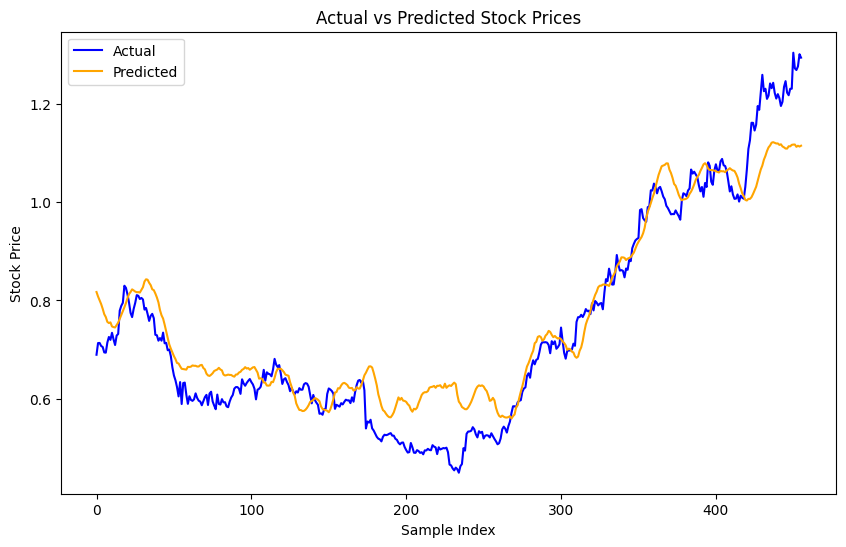

In [124]:

import matplotlib.pyplot as plt

# Make predictions
y_pred = model.predict(X_test)

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(y_test, label="Actual", color='blue')
plt.plot(y_pred, label="Predicted", color='orange')
plt.title("Actual vs Predicted Stock Prices")
plt.xlabel("Sample Index")
plt.ylabel("Stock Price")
plt.legend()
plt.show()




In [125]:
from sklearn.metrics import r2_score

# Calculate R² score
r2 = r2_score(y_test, y_pred)
rmse=np.sqrt(test_loss)

print(f"R² Score: {r2:.6f}")
print(f"RMSE Score: {rmse:.6f}")

R² Score: 0.905605
RMSE Score: 0.142210


In [127]:
# Assuming 'model' is your Keras model
model.save('model.keras')
